# Comparison of the annotators

## Annotator vs GOAT
COmpare how much the annotated images different from the GAOT prediction used as a baseline.

In [81]:
# imports
import os
import sys
from typing import List, Tuple
from tqdm import tqdm
from utils import compute_iou_matrix, instance_matcher


sys.path.append(os.path.dirname(os.getcwd()))

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.model.model import maskRCNNModel
from src.model.engine import FitterMaskRCNN
from src.model.dataset import MaskRCNNDataset
from src.utils.data_utils import *
from src.utils.annotation_utils import *
from src.utils.utils import *
from src.utils.const import *



In [82]:
# dataset_1 = "../dataset/merge_alone_1_corrected_LT"
# dataset_2 = "../dataset/merge_alone_1_corrected_EK"

dataset_1_path = "../dataset/Lucrezia"
dataset_2_path = "../dataset/Ekin"
dataset_3_path = '../dataset/test_multirater_consensus'

# dataset_1 = "../dataset/Ekin_m"
# dataset_2 = "../dataset/Lucrezia_m"

dataset_1 = MaskRCNNDataset(dataset_1_path, datatype="eval", data_augmentation=False)
dataset_2 = MaskRCNNDataset(dataset_2_path, datatype="eval", data_augmentation=False)
dataset_3 = MaskRCNNDataset(dataset_3_path, datatype="eval", data_augmentation=False)

dataset_3_images_paths =[os.path.relpath(dataset_3.images_paths[i], dataset_3_path) for i in range(len(dataset_3))]

print(dataset_1.images_paths[0])

print(f"Dataset 1 length: {len(dataset_1)}, average objects per image: {np.mean([len(dataset_1[i][1]['boxes']) for i in range(len(dataset_1))])}")
print(f"Dataset 2 length: {len(dataset_2)}, average objects per image: {np.mean([len(dataset_2[i][1]['boxes']) for i in range(len(dataset_2))])}")
print(f"Dataset 3 length: {len(dataset_3)}, average objects per image: {np.mean([len(dataset_3[i][1]['boxes']) for i in range(len(dataset_3))])}")

/home/artsy/miniconda3/envs/colorec/lib/python3.12/site-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


../dataset/Lucrezia/images/D284_TREAT_d9/Intermediate_response/4x_XY28_Z001_CH4.tif
Dataset 1 length: 100, average objects per image: 40.93
Dataset 2 length: 100, average objects per image: 60.14
Dataset 3 length: 20, average objects per image: 79.0


## Comapre the two annotators one wrt to the other.

Next we want to avaluate the inter-rater reliability. To do so we compute the precision and recall for varying iou thresholds when considering one of the annotators the ground truth and the opposite.

More specifically, inca se ann1 is the ground turht and ann2 the prediciton, we call:

- **True Positive**: the predictions of ann2 that have been matched to one prediction of ann1 (remark: these associations are unique and reversible).
- **False Positives**: the instances of ann2 that have no matching among the instances from ann1 (the ground truth)
- **False Negatives**: the instances of ann1 (the ground truth) taht have no matching among the instances of ann2

**REMARK**: note that when we invert the ground truth role the TP remanin unchanged (due to the revesibility) and the FP and FN swap.

In [85]:
from copy import deepcopy

# iou_threshold = np.linspace(0.1, 0.9, 20)
iou_thresholds = [0.25, 0.5, 0.75, 0.9]

precisions_1 = []
recalls_1 = []
precisions_2 = []
recalls_2 = []
f1_scores_1 = []
f1_scores_2 = []

for i in range(len(dataset_1)):
    if os.path.relpath(dataset_1.images_paths[i], dataset_1_path) in dataset_3_images_paths:
        print(f"Skipping image {i} as it is in the consensus dataset.")
        continue
    bboxes_annotated_1 = dataset_1[i][1]['boxes'].numpy()
    bboxes_annotated_2 = dataset_2[i][1]['boxes'].numpy()
    if len(bboxes_annotated_1) == 0 or len(bboxes_annotated_2) == 0:
        print(f"One of the annotations is empty. Skipping the image {i}. \nNr. annotated 1: {len(bboxes_annotated_1)} \nNr. annotated 2: {len(bboxes_annotated_2)}")
        continue

    # compute the iou matrix
    iou_matrix = compute_iou_matrix(bboxes_annotated_1, bboxes_annotated_2)
    precisions_1_image = []
    recalls_1_image = []
    precisions_2_image = []
    recalls_2_image = []
    f1_scores_1_image = []
    f1_scores_2_image = []
    for iou_th in iou_thresholds:
        row_ind, col_ind = instance_matcher(deepcopy(iou_matrix), iou_th)
        row_ind_2, col_ind_2 = instance_matcher(deepcopy(iou_matrix.T), iou_th)
        pairs = list(zip(row_ind, col_ind))
        pairs_2 = list(zip(col_ind_2, row_ind_2))
        assert len(pairs) == len(pairs_2), "The number of pairs should be equal."
        for pair in pairs:
            assert pair in pairs_2, f"The pairs should be equal. \nPair: \n{pair} \nPairs_2: \n{pairs_2}"
        # compute the true positives
        true_positives = len(row_ind)
        # compute the false positives
        false_positives_1 = len(bboxes_annotated_1) - len(row_ind)
        false_positives_2= len(bboxes_annotated_2) - len(row_ind)
        # compute the false negatives
        false_negatives_1 = len(bboxes_annotated_2) - len(row_ind)
        false_negatives_2 = len(bboxes_annotated_1) - len(row_ind)
        # compute the precision
        precisions_1_image.append(true_positives / (true_positives + false_positives_1))
        precisions_2_image.append(true_positives / (true_positives + false_positives_2))
        # compute the recall
        recalls_1_image.append(true_positives / (true_positives + false_negatives_1))
        recalls_2_image.append(true_positives / (true_positives + false_negatives_2))
        # compute the f1 score
        f1_scores_1_image.append(2 * (precisions_1_image[-1] * recalls_1_image[-1]) / (precisions_1_image[-1] + recalls_1_image[-1] + 1e-8))
        f1_scores_2_image.append(2 * (precisions_2_image[-1] * recalls_2_image[-1]) / (precisions_2_image[-1] + recalls_2_image[-1] + 1e-8))
    precisions_1.append(precisions_1_image)
    recalls_1.append(recalls_1_image)
    precisions_2.append(precisions_2_image)
    recalls_2.append(recalls_2_image)
    f1_scores_1.append(f1_scores_1_image)
    f1_scores_2.append(f1_scores_2_image)
precisions_1 = np.array(precisions_1)
print(precisions_1.shape)
recalls_1 = np.array(recalls_1)
precisions_2 = np.array(precisions_2)
recalls_2 = np.array(recalls_2)
f1_scores_1 = np.array(f1_scores_1)
f1_scores_2 = np.array(f1_scores_2)



Skipping image 13 as it is in the consensus dataset.
Skipping image 15 as it is in the consensus dataset.
One of the annotations is empty. Skipping the image 23. 
Nr. annotated 1: 0 
Nr. annotated 2: 9
Skipping image 25 as it is in the consensus dataset.
Skipping image 27 as it is in the consensus dataset.
Skipping image 31 as it is in the consensus dataset.
Skipping image 37 as it is in the consensus dataset.
Skipping image 40 as it is in the consensus dataset.
Skipping image 46 as it is in the consensus dataset.
Skipping image 50 as it is in the consensus dataset.
Skipping image 51 as it is in the consensus dataset.
Skipping image 58 as it is in the consensus dataset.
One of the annotations is empty. Skipping the image 59. 
Nr. annotated 1: 4 
Nr. annotated 2: 0
Skipping image 60 as it is in the consensus dataset.
Skipping image 67 as it is in the consensus dataset.
Skipping image 68 as it is in the consensus dataset.
One of the annotations is empty. Skipping the image 70. 
Nr. annot

Mean precision Annotator 1: [0.80052996 0.7696615  0.5549043  0.38866061]
Mean recall Annotator 1: [0.57256961 0.55077203 0.38530291 0.26134643]
Mean precision Annotator 2: [0.57256961 0.55077203 0.38530291 0.26134643]
Mean recall Annotator 2: [0.80052996 0.7696615  0.5549043  0.38866061]


/tmp/ipykernel_29858/3228153494.py:68: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize =(3.4, 3.4), layout='constrained')


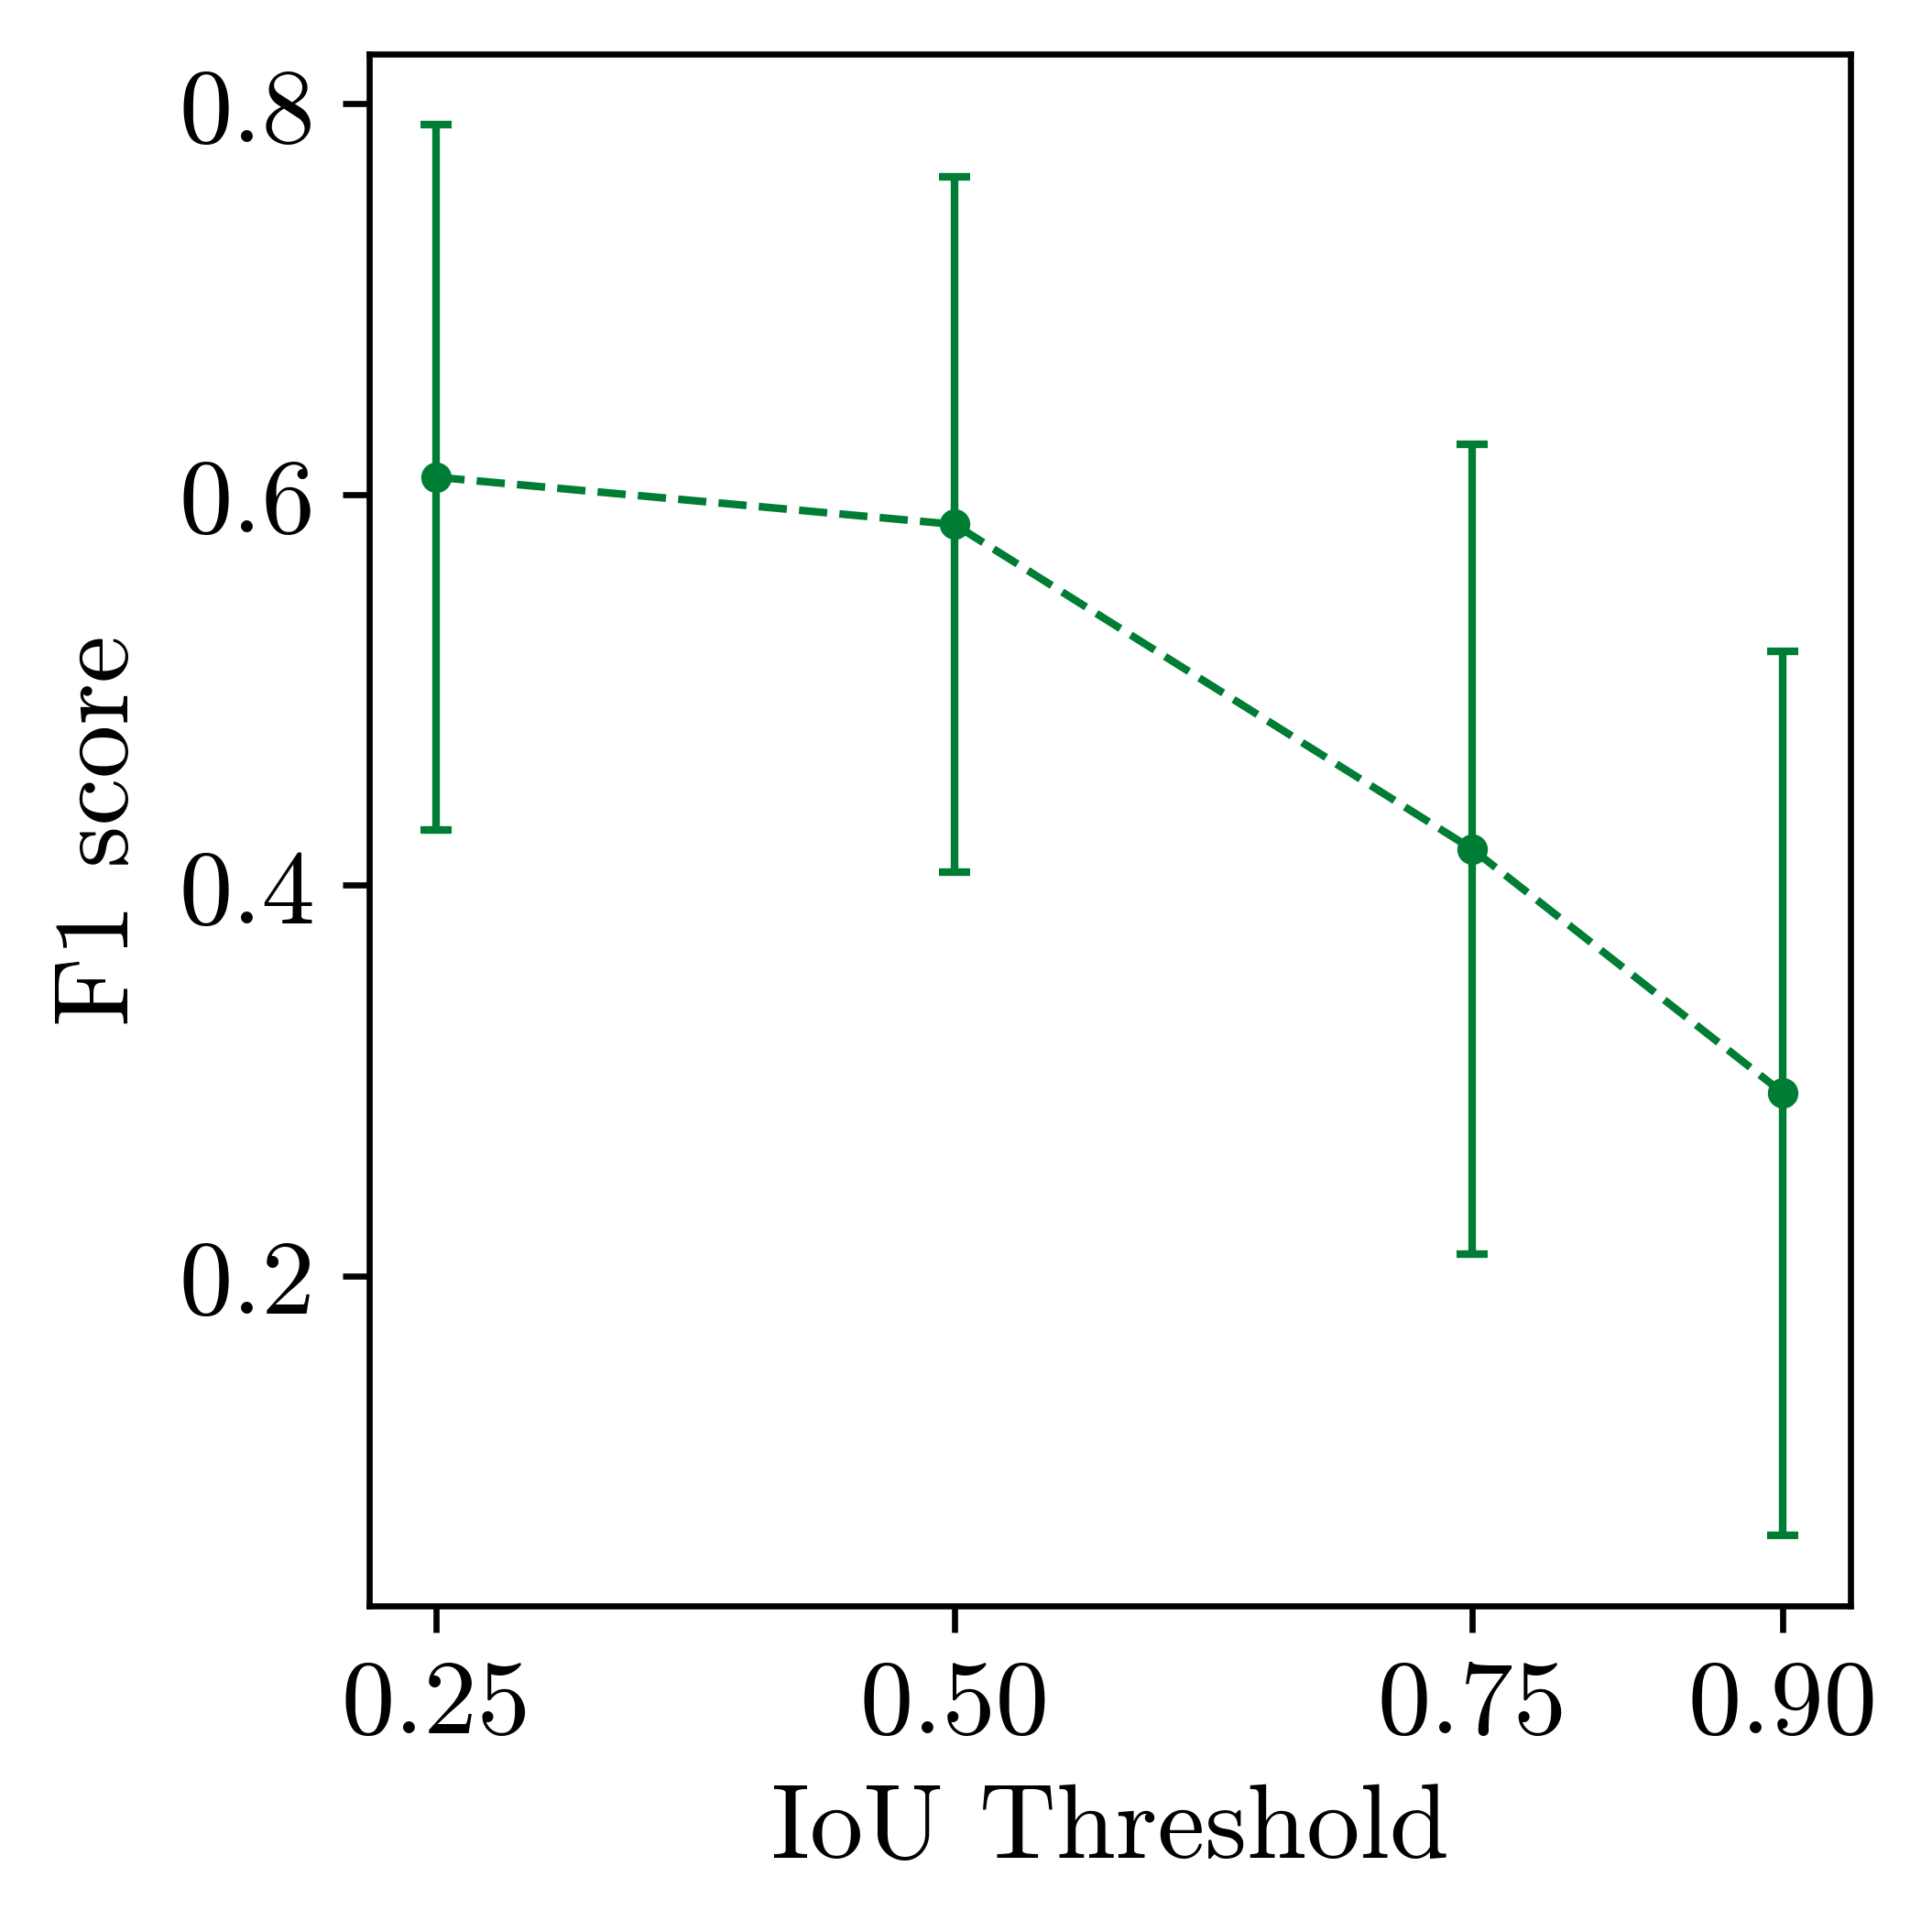

In [114]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",  # Computer Modern
    "font.serif": ["cmr10"],   # internal CM font name
    "font.size": 14,
    "figure.dpi": 600
})
iou_thresholds = [0.25, 0.5, 0.75, 0.9]

f1_scores_1_mean = np.mean(f1_scores_1, axis=0)
f1_scores_1_std = np.std(f1_scores_1, axis=0)
f1_scores_2_mean = np.mean(f1_scores_2, axis=0)
f1_scores_2_std = np.std(f1_scores_2, axis=0)

recalls_1_mean = np.mean(recalls_1, axis=0)
recalls_1_std = np.std(recalls_1, axis=0)
precisions_1_mean = np.mean(precisions_1, axis=0)
precisions_1_std = np.std(precisions_1, axis=0)
recalls_2_mean = np.mean(recalls_2, axis=0)
recalls_2_std = np.std(recalls_2, axis=0)
precisions_2_mean = np.mean(precisions_2, axis=0)
precisions_2_std = np.std(precisions_2, axis=0)

print(f"Mean precision Annotator 1: {precisions_1_mean}")
print(f"Mean recall Annotator 1: {recalls_1_mean}")
print(f"Mean precision Annotator 2: {precisions_2_mean}")
print(f"Mean recall Annotator 2: {recalls_2_mean}")

# recall plot
# fig = plt.subplots(figsize =(12, 8)) 
# plt.plot(iou_threshold, recalls_1_mean, label="Ann. 1", marker="o", linestyle="--")
# plt.fill_between(iou_threshold, recalls_1_mean - recalls_1_std, recalls_1_mean + recalls_1_std, alpha=0.2)
# plt.plot(iou_threshold, recalls_2_mean, label="Ann. 2", marker="o", linestyle="--")
# plt.fill_between(iou_threshold, recalls_2_mean - recalls_2_std, recalls_2_mean + recalls_2_std, alpha=0.2)
# plt.xlabel("IoU Threshold", fontweight ='bold', fontsize = 12)
# plt.ylabel("Recall", fontweight ='bold', fontsize = 12)
# plt.title("Recall comparison", fontweight ='bold', fontsize = 15)
# plt.legend()
# plt.show()

# # precision plot
# fig = plt.subplots(figsize =(12, 8)) 
# plt.plot(iou_threshold, precisions_1_mean, label="Ann. 1", marker="o", linestyle="--")
# plt.fill_between(iou_threshold, precisions_1_mean - precisions_1_std, precisions_1_mean + precisions_1_std, alpha=0.2)
# plt.plot(iou_threshold, precisions_2_mean, label="Ann. 2", marker="o", linestyle="--")
# plt.fill_between(iou_threshold, precisions_2_mean - precisions_2_std, precisions_2_mean + precisions_2_std, alpha=0.2)
# plt.xlabel("IoU Threshold", fontweight ='bold', fontsize = 12)
# plt.ylabel("Precision", fontweight ='bold', fontsize = 12)
# plt.title("Precision comparison", fontweight ='bold', fontsize = 15)
# plt.legend()
# plt.ylim(0, 1)
# plt.show()

# # precision_recall_plot

# fig = plt.subplots(figsize =(12, 8))
# plt.plot(recalls_1_mean, precisions_1_mean, label="Ann. 1", marker="o", linestyle="--")
# plt.plot(recalls_2_mean, precisions_2_mean, label="Ann. 2", marker="o", linestyle="--")
# plt.xlabel("Recall", fontweight ='bold', fontsize = 12)
# plt.ylabel("Precision", fontweight ='bold', fontsize = 12)
# plt.title("Precision-Recall comparison", fontweight ='bold', fontsize = 15)
# plt.legend()
# plt.ylim(0, 1)
# plt.show()

# F1 score
# set figure size
fig, ax = plt.subplots(figsize =(3.4, 3.4), layout='constrained')
# plt.figure(figsize=(3.4, 3.4))
f1_1 = 2 * precisions_1_mean * recalls_1_mean / (precisions_1_mean + recalls_1_mean)
f1_2 = 2 * precisions_2_mean * recalls_2_mean / (precisions_2_mean + recalls_2_mean)
ax.errorbar(iou_thresholds, f1_scores_1_mean, yerr=f1_scores_1_std, marker=".", linestyle="--", capsize=2, linewidth=1, color='#007d34')
# plt.errorbar(iou_threshold, f1_scores_2_mean, yerr=f1_scores_2_std, label="Ann. 2", marker=".", linestyle="--", capsize=2, linewidth=1)
ax.set_xlabel("IoU Threshold")
ax.set_ylabel("F1 score")
ax.set_xticks(iou_thresholds)
# plt.title("F1 score comparison", fontweight ='bold', fontsize = 15)
# plt.tight_layout()
plt.savefig(os.path.join("multi_rater", "f1_inter_rater.pdf"))
plt.show()



## Plot the annotations of the two raters

In the following we plot some images with the annotations of the two raters to visually compare them. In green we have annotations where raters agree, in red the ones that are unique to rater 1 and in yellow the ones that are unique to rater 2.

Plotting image 84 / 100


/tmp/ipykernel_29858/59974239.py:41: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.imshow(image, aspect='equal')


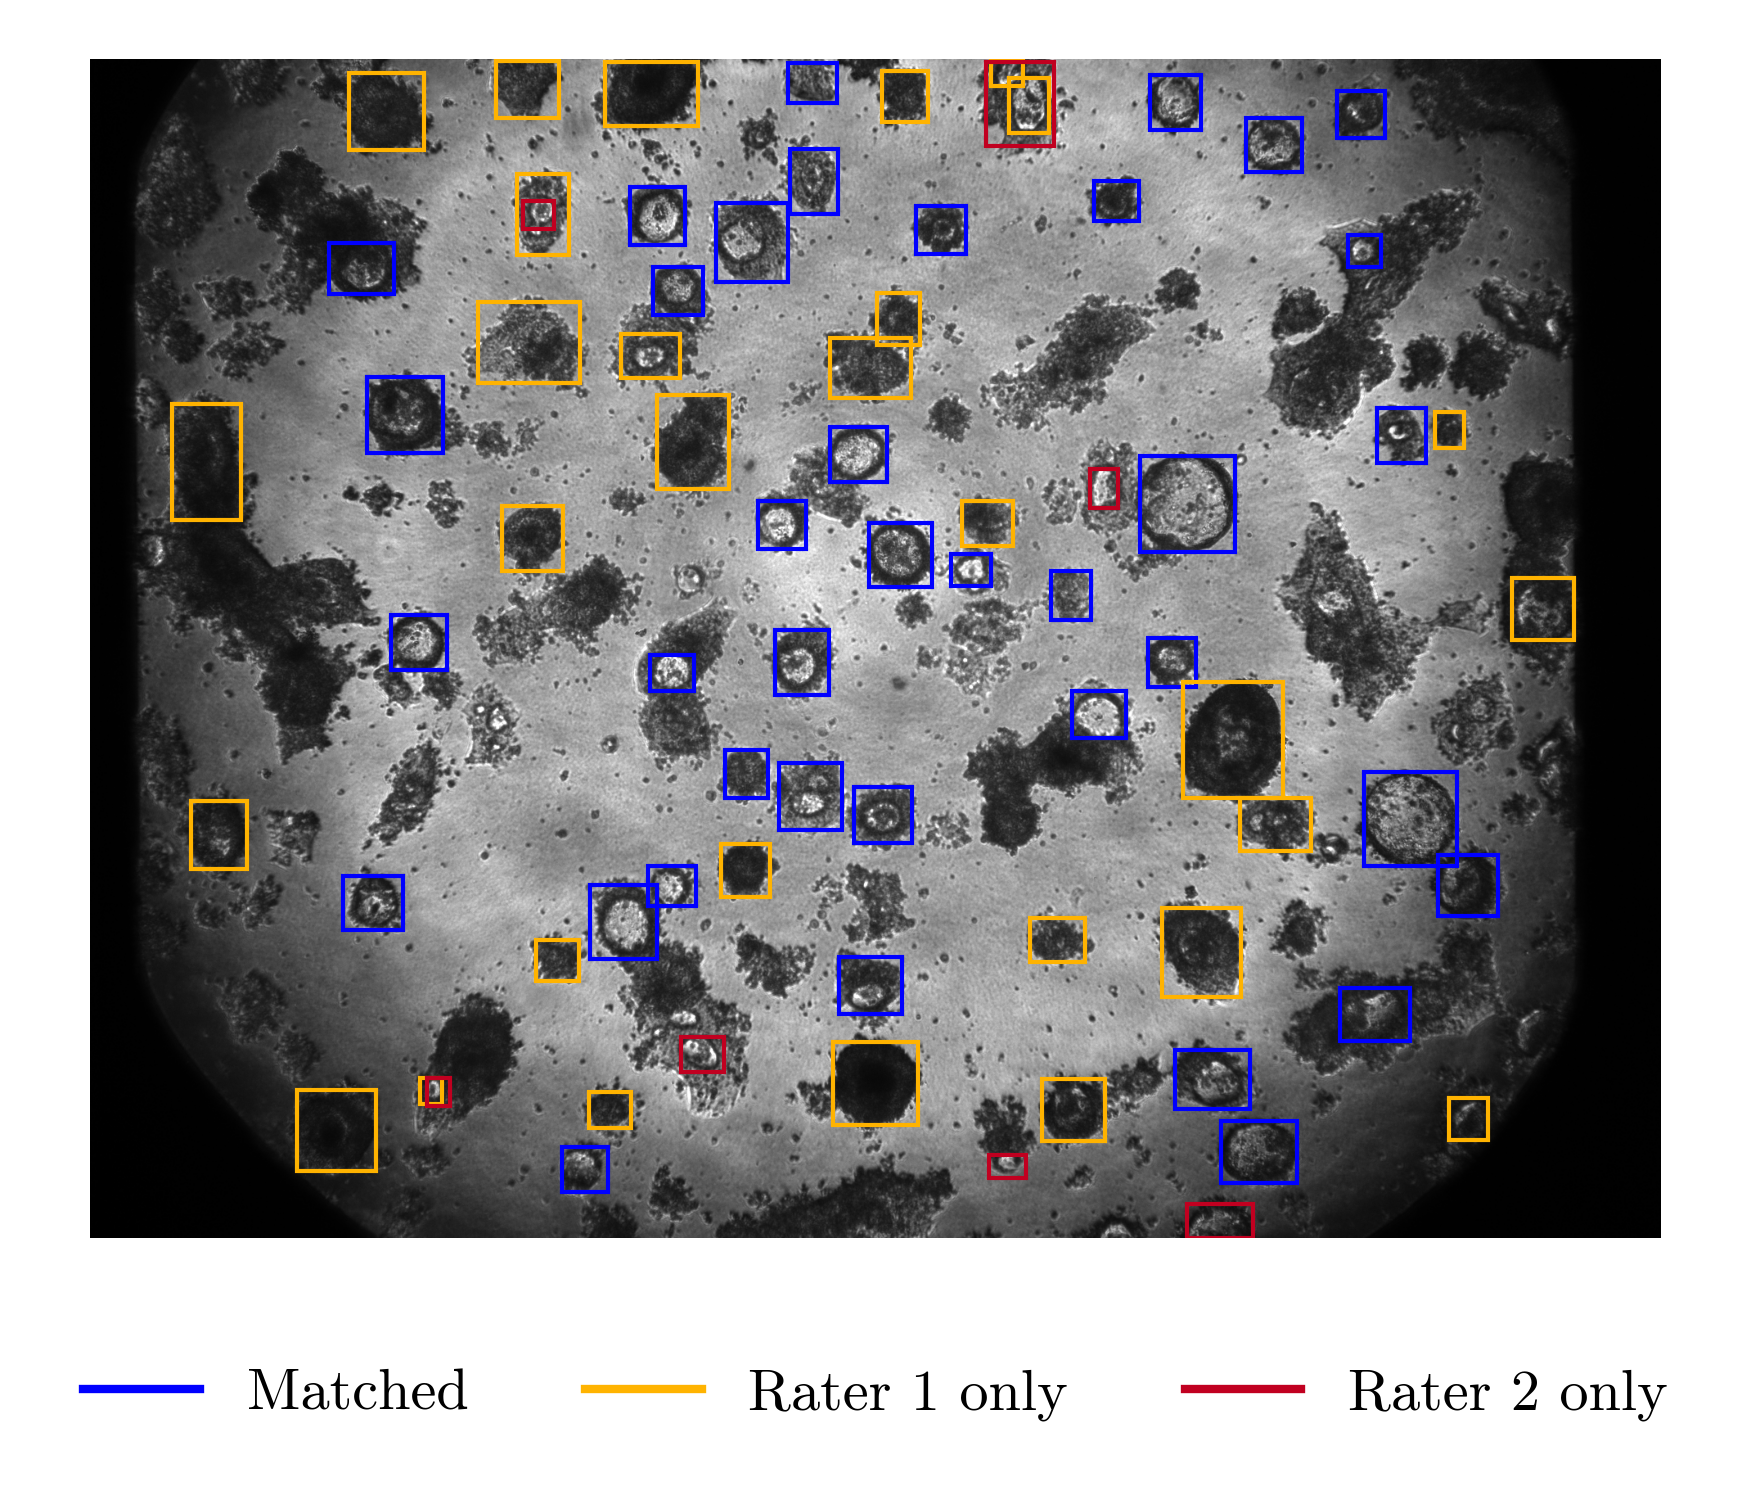

In [112]:
# set plot parameters
from copy import deepcopy

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",  # Computer Modern
    "font.serif": ["cmr10"],   # internal CM font name
    "font.size": 7,
    "figure.dpi": 600
})
width = 3.4  # width in inches

for i in range(len(dataset_1)):
    # check if the image is also ni dataset 3
    if i != 84:
        continue
    print(f"Plotting image {i} / {len(dataset_1)}")
    image = dataset_1[i][0].permute(1, 2, 0).numpy()
    # remove black borders from the image
    left = 0
    right = image.shape[1] - 1
    for col in range(image.shape[1]):
        if np.sum(image[:, col, :]) > 0:
            left = col
            break
    for col in range(image.shape[1]-1, -1, -1):
        if np.sum(image[:, col, :]) > 0:
            right = col
            break
    image = image[:, left:right+1, :]

    bboxes_annotated_1 = dataset_1[i][1]['boxes'].numpy()
    bboxes_annotated_2 = dataset_2[i][1]['boxes'].numpy()
    if len(bboxes_annotated_1) == 0 or len(bboxes_annotated_2) == 0:
        continue
    iou_matrix = compute_iou_matrix(bboxes_annotated_1, bboxes_annotated_2)
    row_ind, col_ind = instance_matcher(deepcopy(iou_matrix), 0.5)

    height = width * image.shape[0] / image.shape[1] # maintain aspect ratio
    plt.figure(figsize=(width, height))
    plt.imshow(image, aspect='equal')
    ax = plt.gca()

    # plot matched boxes in green
    for r, c in zip(row_ind, col_ind):
        box_1 = bboxes_annotated_1[r]
        box_2 = bboxes_annotated_2[c]
        x_min = min(box_1[0], box_2[0])
        y_min = min(box_1[1], box_2[1])
        x_max = max(box_1[2], box_2[2])
        y_max = max(box_1[3], box_2[3])
        rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                             linewidth=0.5, edgecolor='blue', facecolor='none')
        ax.add_patch(rect)

    # plot unmatched boxes in red (annotator 1) and yellow (annotator 2)
    for r, box in enumerate(bboxes_annotated_2):
        if r not in col_ind:
            x_min, y_min, x_max, y_max = box
            rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                 linewidth=0.5, edgecolor='#ffb300', facecolor='none')
            ax.add_patch(rect)

    for r, box in enumerate(bboxes_annotated_1):
        if r not in row_ind:
            x_min, y_min, x_max, y_max = box
            rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                 linewidth=0.5, edgecolor='#c10020', facecolor='none')
            ax.add_patch(rect)

    # create legend and locate it outside the plot
    green_patch = plt.Line2D([0], [0], color='blue', lw=1, label='Matched')
    red_patch = plt.Line2D([0], [0], color='#ffb300', lw=1, label='Rater 1 only')
    yellow_patch = plt.Line2D([0], [0], color='#c10020', lw=1, label='Rater 2 only')
    plt.legend(handles=[green_patch, red_patch, yellow_patch], loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)


    plt.axis('off')
    plt.savefig(os.path.join("annotators_comparison", f"image_{i}.pdf"), bbox_inches='tight', pad_inches=0.0, format='pdf')
    plt.show()

# Investigate the distribution of the number of predictions

In [12]:


iou_threshold = np.linspace(0.1, 0.9, 10)

n_pred_1 = []
n_pred_2 = []

for i in range(len(dataset_1)):
    bboxes_annotated_1 = dataset_1[i][1]['boxes'].numpy()
    bboxes_annotated_2 = dataset_2[i][1]['boxes'].numpy()


    n_pred_1.append(len(bboxes_annotated_1))
    n_pred_2.append(len(bboxes_annotated_2))

# plot the two distributions

plt.figure(figsize=(3.4, 3.4))
plt.hist(n_pred_1, bins=10, alpha=0.5, label='Rater 1')
plt.hist(n_pred_2, bins=10, alpha=0.5, label='Rater 2')
plt.xlabel('Number of annotated objects per image')
plt.ylabel('Number of images')
plt.legend()
plt.tight_layout()
plt.show()
    

## Actions on the predictions: how many have been kept, added or removed from the baseline model

In [88]:
# initialize model
device='cpu'
model = maskRCNNModel()
model.load_state_dict(load_pretrained_weights(device=device))
model.eval()
print("Model loaded.")

# evaluate the model on one dataset
engine = FitterMaskRCNN(device=device)
collate_fn = lambda x: tuple(zip(*x))
loader = torch.utils.data.DataLoader(dataset_1, batch_size=4, shuffle=False, collate_fn=collate_fn)
loader_3 = torch.utils.data.DataLoader(dataset_3, batch_size=4, shuffle=False, collate_fn=collate_fn)
model_predictions, metrics = engine.evaluate_one_epoch_predictions(model, loader, 0.9)
model_predictions_3, metrics_3 = engine.evaluate_one_epoch_predictions(model, loader_3, 0.9)
print("Evaluation on dataset 1 done.")

# match with annotations
kept_1 = []
kept_2 = []
added_1 = []
added_2 = []
removed_1 = []
removed_2 = []
total_1 = []
total_2 = []
for i in range(len(dataset_1)):
    if os.path.relpath(dataset_1.images_paths[i], dataset_1_path) in dataset_3_images_paths:
        print(f"Skipping image {i} as it is in the consensus dataset.")
        continue
    bboxes_annotated_1 = dataset_1[i][1]['boxes'].numpy()
    bboxes_annotated_2 = dataset_2[i][1]['boxes'].numpy()
    bboxes_predicted = model_predictions[i]['boxes'].cpu().numpy()
    iou_matrix_1 = compute_iou_matrix(bboxes_annotated_1, bboxes_predicted)
    iou_matrix_2 = compute_iou_matrix(bboxes_annotated_2, bboxes_predicted)

    row_ind_1, col_ind_1 = instance_matcher(deepcopy(iou_matrix_1), 0.5)
    row_ind_2, col_ind_2 = instance_matcher(deepcopy(iou_matrix_2), 0.5)
    kept_1.append(len(row_ind_1))
    kept_2.append(len(row_ind_2))
    added_1.append(len(bboxes_annotated_1) - len(row_ind_1))
    added_2.append(len(bboxes_annotated_2) - len(row_ind_2))
    removed_1.append(len(bboxes_predicted) - len(col_ind_1))
    removed_2.append(len(bboxes_predicted) - len(col_ind_2))
    total_1.append(len(bboxes_annotated_1))
    total_2.append(len(bboxes_annotated_2))
print("Matching done.")

# same for the consensus dataset
kept_3 = []
added_3 = []
removed_3 = []
total_3 = []
for i in range(len(dataset_3)):
    bboxes_annotated_3 = dataset_3[i][1]['boxes'].numpy()
    bboxes_predicted = model_predictions_3[i]['boxes'].cpu().numpy()
    iou_matrix_3 = compute_iou_matrix(bboxes_annotated_3, bboxes_predicted)

    row_ind_3, col_ind_3 = instance_matcher(deepcopy(iou_matrix_3), 0.5)
    kept_3.append(len(row_ind_3))
    added_3.append(len(bboxes_annotated_3) - len(row_ind_3))
    removed_3.append(len(bboxes_predicted) - len(col_ind_3))
    total_3.append(len(bboxes_annotated_3))


Model loaded.


100%|██████████| 20/20 [00:42<00:00,  2.10s/it]


Evaluation on dataset 1 done.
Skipping image 13 as it is in the consensus dataset.
Skipping image 15 as it is in the consensus dataset.
Skipping image 25 as it is in the consensus dataset.
Skipping image 27 as it is in the consensus dataset.
Skipping image 31 as it is in the consensus dataset.
Skipping image 37 as it is in the consensus dataset.
Skipping image 40 as it is in the consensus dataset.
Skipping image 46 as it is in the consensus dataset.
Skipping image 50 as it is in the consensus dataset.
Skipping image 51 as it is in the consensus dataset.
Skipping image 58 as it is in the consensus dataset.
Skipping image 60 as it is in the consensus dataset.
Skipping image 67 as it is in the consensus dataset.
Skipping image 68 as it is in the consensus dataset.
Skipping image 76 as it is in the consensus dataset.
Skipping image 77 as it is in the consensus dataset.
Skipping image 87 as it is in the consensus dataset.
Skipping image 90 as it is in the consensus dataset.
Skipping image 9

/tmp/ipykernel_29858/3546007981.py:12: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize =(3.4, 3.4), layout='constrained')


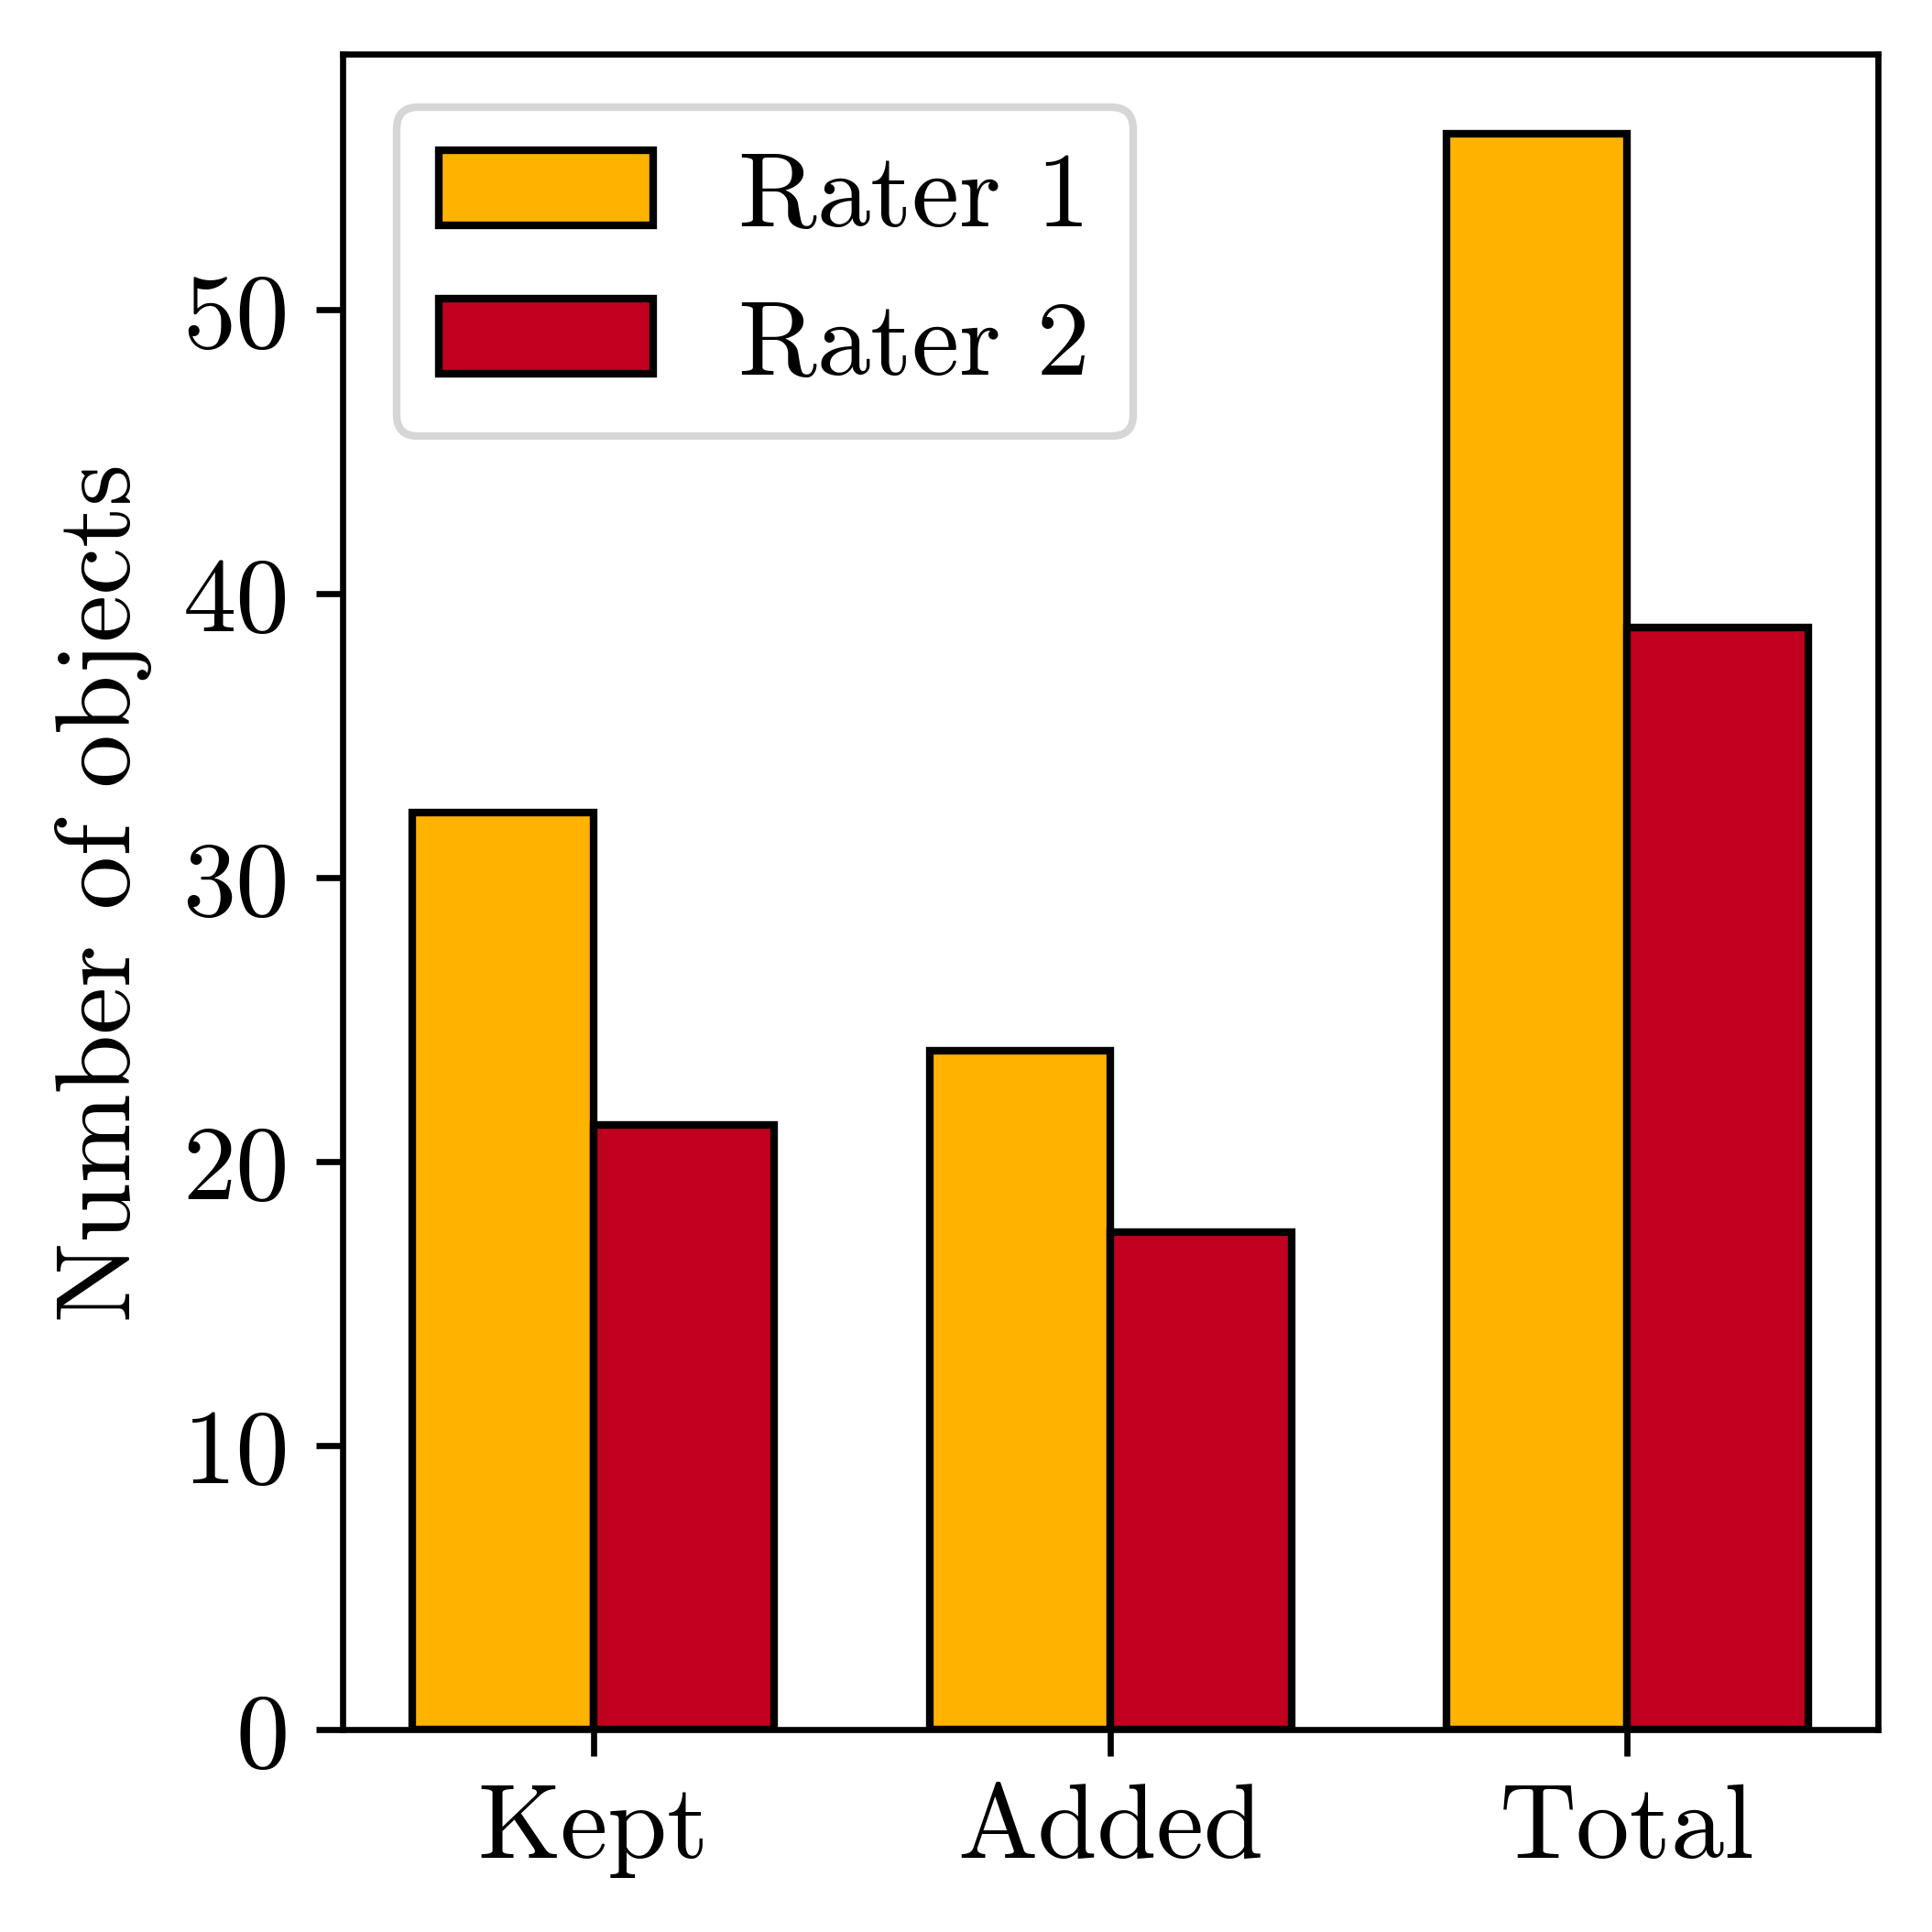

In [99]:
from statistics import mean, stdev

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",  # Computer Modern
    "font.serif": ["cmr10"],   # internal CM font name
    "font.size": 14,
    "figure.dpi": 600
})

barWidth = 0.35
fig, ax = plt.subplots(figsize =(3.4, 3.4), layout='constrained') 

# set height of bar 
ANN_1 = [mean(x) for x in [kept_1, added_1, total_1]]
ERR_1 = [stdev(x) for x in [kept_1, added_1, total_1]]
ANN_2 = [mean(x) for x in [kept_2, added_2, total_2]]
ERR_2 = [stdev(x) for x in [kept_2,  added_2, total_2]]
ANN_3 = [mean(x) for x in [kept_3, added_3, total_3]]
ERR_3 = [stdev(x) for x in [kept_3, added_3, total_3]]

# Set position of bar on X axis 
br1 = np.arange(len(ANN_1)) 
br2 = [x + barWidth for x in br1] 
b3_3 = [x + barWidth for x in br2]

# Make the plot
ax.bar(br1, ANN_2, width = barWidth, label ='Rater 1', edgecolor='black', color='#ffb300')
ax.bar(br2, ANN_1, width = barWidth, label ='Rater 2', edgecolor='black', color='#c10020')
# ax.bar(b3_3, ANN_3, width = barWidth, label ='Consensus', edgecolor='black', color='tab:blue')


# Adding Xticks 
# plt.xlabel('Type of action') 
ax.set_ylabel('Number of objects') 
# plt.ylim(0, 80)
ax.set_xticks([r + barWidth/2 for r in br1], 
        ['Kept',  'Added', 'Total'])
#locate in upepr center 
ax.legend(loc='upper left')
# plt.title("Comparison of the annotations (absolute values)")
plt.savefig(os.path.join("multi_rater", "annotation_comparison_absolute.pdf"))
plt.show()

In [91]:
# avg number of annotations between the two annotators and the consensus

tot_1 = []
tot_2 = []
tot_3 = []

for i in range(len(dataset_1)):
    if os.path.relpath(dataset_1.images_paths[i], dataset_1_path) in dataset_3_images_paths:
        bboxes_annotated_1 = dataset_1[i][1]['boxes'].numpy()
        bboxes_annotated_2 = dataset_2[i][1]['boxes'].numpy()
        tot_1.append(len(bboxes_annotated_1))
        tot_2.append(len(bboxes_annotated_2))
for i in range(len(dataset_3)):
    bboxes_annotated_3 = dataset_3[i][1]['boxes'].numpy()
    tot_3.append(len(bboxes_annotated_3))

print(f"Average number of annotations Rater 1: {mean(tot_1)} ± {stdev(tot_1)}")
print(f"Average number of annotations Rater 2: {mean(tot_2)} ± {stdev(tot_2)}")
print(f"Average number of annotations Consensus: {mean(tot_3)} ± {stdev(tot_3)}")

Skipping image 13 as it is in the consensus dataset.
Skipping image 15 as it is in the consensus dataset.
Skipping image 25 as it is in the consensus dataset.
Skipping image 27 as it is in the consensus dataset.
Skipping image 31 as it is in the consensus dataset.
Skipping image 37 as it is in the consensus dataset.
Skipping image 40 as it is in the consensus dataset.
Skipping image 46 as it is in the consensus dataset.
Skipping image 50 as it is in the consensus dataset.
Skipping image 51 as it is in the consensus dataset.
Skipping image 58 as it is in the consensus dataset.
Skipping image 60 as it is in the consensus dataset.
Skipping image 67 as it is in the consensus dataset.
Skipping image 68 as it is in the consensus dataset.
Skipping image 76 as it is in the consensus dataset.
Skipping image 77 as it is in the consensus dataset.
Skipping image 87 as it is in the consensus dataset.
Skipping image 90 as it is in the consensus dataset.
Skipping image 93 as it is in the consensus da

Plot the distribution of the sizes

IDEA clould plot the ones having the most significant difference in distribution... -> remember to correct the test 

In [ ]:
sizes_1_flat = [item for sublist in sizes_1 for item in sublist]
sizes_2_flat = [item for sublist in sizes_2 for item in sublist]

fig = plt.subplots(figsize =(12, 8))
plt.hist(sizes_1_flat, bins=30, alpha=0.5, label="Annotator 1")
plt.hist(sizes_2_flat, bins=30, alpha=0.5, label="Annotator 2")
plt.xlabel("Diameter of the bounding box", fontweight ='bold', fontsize = 12)
plt.ylabel("Density", fontweight ='bold', fontsize = 12)
plt.title("Comparison of the bounding box sizes", fontweight ='bold', fontsize = 15)
plt.legend()
plt.show()

fig = plt.subplots(figsize =(12, 8))
plt.hist(sizes_1_flat, bins=50, alpha=0.5, label="Annotator 1", density=True)
plt.hist(sizes_2_flat, bins=50, alpha=0.5, label="Annotator 2", density=True)
plt.xlabel("Diameter of the bounding box", fontweight ='bold', fontsize = 12)
plt.ylabel("Density", fontweight ='bold', fontsize = 12)
plt.title("Comparison of the bounding box sizes (density)", fontweight ='bold', fontsize = 15)
plt.legend()
plt.show()

In [ ]:
from copy import deepcopy
import cv2
from matplotlib.lines import Line2D

iou_threshold = 0.5
predictions = pickle.load(open("predictions.pkl", "rb"))

id = 0
for annotation_path_1, annotation_path_2, (image_norm, meta), bbxes_predicitons in zip(annotations_1_paths, annotations_2_paths, inference_ds, predictions):
    if not os.path.exists(annotation_path_1):
        warnings.warn(f"Annotations path {annotation_path_1} does not exist. Skipping the image.")
        continue
    if not os.path.exists(annotation_path_2):
        warnings.warn(f"Annotations path {annotation_path_2} does not exist. Skipping the image.")
        continue

    # load the annotations
    bboxes_annotated_1 = pd.read_csv(annotation_path_1, index_col=0, sep=",")
    bboxes_annotated_1 = bbox_xyxy_to_box(bboxes_annotated_1)
    nr_annotated_1 = len(bboxes_annotated_1)

    bboxes_annotated_2 = pd.read_csv(annotation_path_2, index_col=0, sep=",")
    bboxes_annotated_2 = bbox_xyxy_to_box(bboxes_annotated_2)
    nr_annotated_2 = len(bboxes_annotated_2)

    # compute the iou matrix
    iou_matrix = compute_iou_matrix(bboxes_annotated_1, bboxes_annotated_2)
    # print("Intersection over union matrix")
    # for i in range(iou_matrix.shape[0]):
    #     for j in range(iou_matrix.shape[1]):
    #         if iou_matrix[i, j] > 0:
    #             print(f"ID: {i} - {j}: {iou_matrix[i, j]}")
    true_positives_1, true_positives_2 = instance_matcher(deepcopy(iou_matrix), iou_threshold)

    # print("True positives")
    # for i, j in zip(true_positives_1, true_positives_2):
    #     print(f"ID: {i} - {j}: {compute_iou(bboxes_annotated_1[i], bboxes_annotated_2[j])}")        
    # compute the false positives
    false_positives_1 = [i for i in range(len(bboxes_annotated_1)) if i not in true_positives_1]
    false_positives_2 = [i for i in range(len(bboxes_annotated_2)) if i not in true_positives_2]

    # load the image
    image_path = meta["path"]
    print(image_path)
    image_1 = cv2.imread(image_path)
    image_2 = cv2.imread(image_path)
    image_3 = cv2.imread(image_path)
    # draw the true positives from the baseline in blue and gree the ones from the annotator
    def from_baseline(bbox, bboes_prediction):
        for b in bboes_prediction:
            if compute_iou(bbox, b) >= 0.5:
                return True
        return False
    
    for bbox in bbxes_predicitons:
        cv2.rectangle(image_3, (bbox.right, bbox.top), (bbox.left, bbox.bottom), (0, 0, 255), 2)

    for i in true_positives_1:
        bbox = bboxes_annotated_1[i]
        color = (0, 0, 255) if from_baseline(bbox, bbxes_predicitons) else (0, 255, 0)
        cv2.rectangle(image_1, (bbox.right, bbox.top), (bbox.left, bbox.bottom), color, 2)
        cv2.putText(image_1, f"ID: {i}", (bbox.right, bbox.bottom-10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    for i in true_positives_2:
        bbox = bboxes_annotated_2[i]
        color =  (0, 0, 255) if from_baseline(bbox, bbxes_predicitons) else (0, 255, 0)
        cv2.rectangle(image_2, (bbox.right, bbox.top), (bbox.left, bbox.bottom), color, 2)
        cv2.putText(image_2, f"ID: {i}", (bbox.right, bbox.bottom-10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    # draw the false positives in red
    for i in false_positives_1:
        bbox = bboxes_annotated_1[i]
        color = (255, 255, 0) if from_baseline(bbox, bbxes_predicitons) else (255, 0, 0)
        cv2.rectangle(image_1, (bbox.right, bbox.top), (bbox.left, bbox.bottom), color, 2)
        cv2.putText(image_1, f"ID: {i}", (bbox.right, bbox.bottom-10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    for i in false_positives_2:
        bbox = bboxes_annotated_2[i]
        color = (255, 255, 0) if from_baseline(bbox, bbxes_predicitons) else (255, 0, 0)
        cv2.rectangle(image_2, (bbox.right, bbox.top), (bbox.left, bbox.bottom), color, 2)
        cv2.putText(image_2, f"ID: {i}", (bbox.right, bbox.bottom-10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    fig, ax = plt.subplots(1, 3, figsize= (24, 7))
    ax[0].imshow(image_1)
    ax[0].set_title("Annotator 1", fontweight ='bold', fontsize = 12)
    ax[1].imshow(image_2)
    ax[1].set_title("Annotator 2", fontweight ='bold', fontsize = 12)
    ax[2].imshow(image_3)
    ax[2].set_title("Baseline", fontweight ='bold', fontsize = 12)
    fig.suptitle(f"Image {id}", fontweight ='bold', fontsize = 15)
    line_green  = Line2D([0], [0], label='matched annotated', color='green')
    line_blue = Line2D([0], [0], label='matched baseline', color='blue')
    line_red = Line2D([0], [0], label='unmatched annotated', color='red')
    line_yellow = Line2D([0], [0], label='unmatched baseline', color='yellow')
    fig.legend(handles=[line_green, line_blue, line_red, line_yellow])
    plt.show()


    
    id += 1
    


In [ ]:
from copy import deepcopy
import cv2
from matplotlib.lines import Line2D

iou_threshold = 0.5
predictions = pickle.load(open("predictions.pkl", "rb"))

id = 0
for annotation_path_1, annotation_path_2, (image_norm, meta), bbxes_predicitons in zip(annotations_1_paths, annotations_2_paths, inference_ds, predictions):
    if not os.path.exists(annotation_path_1):
        warnings.warn(f"Annotations path {annotation_path_1} does not exist. Skipping the image.")
        continue
    if not os.path.exists(annotation_path_2):
        warnings.warn(f"Annotations path {annotation_path_2} does not exist. Skipping the image.")
        continue

    # load the annotations
    bboxes_annotated_1 = pd.read_csv(annotation_path_1, index_col=0, sep=",")
    bboxes_annotated_1 = bbox_xyxy_to_box(bboxes_annotated_1)
    nr_annotated_1 = len(bboxes_annotated_1)

    bboxes_annotated_2 = pd.read_csv(annotation_path_2, index_col=0, sep=",")
    bboxes_annotated_2 = bbox_xyxy_to_box(bboxes_annotated_2)
    nr_annotated_2 = len(bboxes_annotated_2)

    # compute the iou matrix
    iou_matrix = compute_iou_matrix(bboxes_annotated_1, bboxes_annotated_2)
    # print("Intersection over union matrix")
    # for i in range(iou_matrix.shape[0]):
    #     for j in range(iou_matrix.shape[1]):
    #         if iou_matrix[i, j] > 0:
    #             print(f"ID: {i} - {j}: {iou_matrix[i, j]}")
    true_positives_1, true_positives_2 = instance_matcher(deepcopy(iou_matrix), iou_threshold)

    # print("True positives")
    # for i, j in zip(true_positives_1, true_positives_2):
    #     print(f"ID: {i} - {j}: {compute_iou(bboxes_annotated_1[i], bboxes_annotated_2[j])}")        
    # compute the false positives
    false_positives_1 = [i for i in range(len(bboxes_annotated_1)) if i not in true_positives_1]
    false_positives_2 = [i for i in range(len(bboxes_annotated_2)) if i not in true_positives_2]

    # load the image
    image_path = meta["path"]
    print(image_path)
    image_1 = cv2.imread(image_path)
    image_2 = cv2.imread(image_path)
    

    for i in true_positives_1:
        bbox = bboxes_annotated_1[i]
        color = (0, 255, 0)
        cv2.rectangle(image_1, (bbox.right, bbox.top), (bbox.left, bbox.bottom), color, 2)
        cv2.putText(image_1, f"ID: {i}", (bbox.right, bbox.bottom-10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    for i in true_positives_2:
        bbox = bboxes_annotated_2[i]
        color =  (0, 255, 0)
        cv2.rectangle(image_2, (bbox.right, bbox.top), (bbox.left, bbox.bottom), color, 2)
        cv2.putText(image_2, f"ID: {i}", (bbox.right, bbox.bottom-10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    # draw the false positives in red
    for i in false_positives_1:
        bbox = bboxes_annotated_1[i]
        color = (255, 0, 0)
        cv2.rectangle(image_1, (bbox.right, bbox.top), (bbox.left, bbox.bottom), color, 2)
        cv2.putText(image_1, f"ID: {i}", (bbox.right, bbox.bottom-10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    for i in false_positives_2:
        bbox = bboxes_annotated_2[i]
        color = (255, 0, 0)
        cv2.rectangle(image_2, (bbox.right, bbox.top), (bbox.left, bbox.bottom), color, 2)
        cv2.putText(image_2, f"ID: {i}", (bbox.right, bbox.bottom-10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    fig, ax = plt.subplots(1, 2, figsize= (18, 7))
    ax[0].imshow(image_1)
    ax[0].set_title("Annotator 1", fontweight ='bold', fontsize = 12)
    ax[1].imshow(image_2)
    ax[1].set_title("Annotator 2", fontweight ='bold', fontsize = 12)
    fig.suptitle(f"Image {id}", fontweight ='bold', fontsize = 15)
    line_green  = Line2D([0], [0], label='matched annotations', color='green')
    line_red = Line2D([0], [0], label='unmatched annotations', color='red')
    fig.legend(handles=[line_green, line_red])
    plt.show()


    
    id += 1

In [ ]:
import sys
import os
import shutil
# sys.path.append(os.path.dirname(os.getcwd()))
from src.utils.const import *
from src.utils.utils import *

# path = "../dataset/reannotate_dataset.txt"
# old_dataset = "../dataset/merge_05"
# new_dataset_1 = "../dataset/merge_together"
# new_dataset_2 = "../dataset/merge_alone"
# with open(path, "r") as h:
#     files = h.readlines()
#     files = [file.strip() for file in files]

# images_paths = get_images_paths(old_dataset)
# images_paths = [os.path.relpath(image_path, os.path.join(old_dataset, IMAGES_SUBFOLDER)) for image_path in images_paths]
# i = 1
# for image_path in images_paths:
#     annotation_path = image_to_annotations_path(image_path, BBOXES_SUFF)
#     if image_path in files:
#         print(i)
#         i+=1
#         new_dataset = new_dataset_1
#     else:
#         new_dataset = new_dataset_2
#     os.makedirs(os.path.join(new_dataset, IMAGES_SUBFOLDER, os.path.dirname(image_path)), exist_ok=True)
#     os.makedirs(os.path.join(new_dataset, ANNOTATIONS_SUBFOLDER, os.path.dirname(annotation_path)), exist_ok=True)
#     shutil.copyfile(os.path.join(old_dataset, IMAGES_SUBFOLDER, image_path), os.path.join(new_dataset, IMAGES_SUBFOLDER, image_path))
#     shutil.copyfile(os.path.join(old_dataset, ANNOTATIONS_SUBFOLDER, annotation_path), os.path.join(new_dataset, ANNOTATIONS_SUBFOLDER, annotation_path))
    



In [ ]:
# import sys
# import os
# import shutil
# import random
# sys.path.append(os.path.dirname(os.getcwd()))
# from src.utils.const import *
# from src.utils.utils import *


# old_dataset = "../dataset/merge_alone"
# new_dataset = "../dataset/merge_alone_1"


# images_paths = get_images_paths(old_dataset)
# print(len(images_paths))
# images_paths = [os.path.relpath(image_path, os.path.join(old_dataset, IMAGES_SUBFOLDER)) for image_path in images_paths]
# random.seed(42)
# sampled_images_paths = random.sample(images_paths, 20) # sample randomly 20 images

# for image_path in sampled_images_paths:
#     print(image_path)
#     annotation_path = image_to_annotations_path(image_path, BBOXES_SUFF)
#     os.makedirs(os.path.join(new_dataset, IMAGES_SUBFOLDER, os.path.dirname(image_path)), exist_ok=True)
#     os.makedirs(os.path.join(new_dataset, ANNOTATIONS_SUBFOLDER, os.path.dirname(annotation_path)), exist_ok=True)
#     shutil.copyfile(os.path.join(old_dataset, IMAGES_SUBFOLDER, image_path), os.path.join(new_dataset, IMAGES_SUBFOLDER, image_path))
#     shutil.copyfile(os.path.join(old_dataset, ANNOTATIONS_SUBFOLDER, annotation_path), os.path.join(new_dataset, ANNOTATIONS_SUBFOLDER, annotation_path))

In [ ]:
# import sys
# import os
# import shutil
# import random
# sys.path.append(os.path.dirname(os.getcwd()))
# from src.utils.const import *
# from src.utils.utils import *


# dataset = "../dataset/merge" # all the images
# dataset_1 = "../dataset/merge_together" # the images that are corrected together
# dataset_2 = "../dataset/merge_alone_1" # the images that are corrected alone


# images_path = get_images_paths(dataset)
# images_path = [os.path.relpath(image_path, os.path.join(dataset, IMAGES_SUBFOLDER)) for image_path in images_path]
# images_path_1 = get_images_paths(dataset_1)
# images_path_1 = [os.path.relpath(image_path, os.path.join(dataset_1, IMAGES_SUBFOLDER)) for image_path in images_path_1]
# images_path_2 = get_images_paths(dataset_2)
# images_path_2 = [os.path.relpath(image_path, os.path.join(dataset_2, IMAGES_SUBFOLDER)) for image_path in images_path_2]

# images_path_remaining = list(set(images_path) - set(images_path_1) - set(images_path_2))

# random.seed(42)
# sampled_images_1 = random.sample(images_path_remaining, 30) # sample randomly 30 images
# sampled_images_2 = list(set(images_path_remaining) - set(sampled_images_1))
# print(len(sampled_images_1))
# print(len(sampled_images_2))

# dataset_new_1 = "../dataset/merge_alone_2_LT"
# for image_path in sampled_images_1:
#     annotation_path = image_to_annotations_path(image_path, BBOXES_SUFF)
#     os.makedirs(os.path.join(dataset_new_1, IMAGES_SUBFOLDER, os.path.dirname(image_path)), exist_ok=True)
#     os.makedirs(os.path.join(dataset_new_1, ANNOTATIONS_SUBFOLDER, os.path.dirname(annotation_path)), exist_ok=True)
#     shutil.copyfile(os.path.join(dataset, IMAGES_SUBFOLDER, image_path), os.path.join(dataset_new_1, IMAGES_SUBFOLDER, image_path))
#     shutil.copyfile(os.path.join(dataset, ANNOTATIONS_SUBFOLDER, annotation_path), os.path.join(dataset_new_1, ANNOTATIONS_SUBFOLDER, annotation_path))

# dataset_new_2 = "../dataset/merge_alone_2_EK"
# for image_path in sampled_images_2:
#     annotation_path = image_to_annotations_path(image_path, BBOXES_SUFF)
#     os.makedirs(os.path.join(dataset_new_2, IMAGES_SUBFOLDER, os.path.dirname(image_path)), exist_ok=True)
#     os.makedirs(os.path.join(dataset_new_2, ANNOTATIONS_SUBFOLDER, os.path.dirname(annotation_path)), exist_ok=True)
#     shutil.copyfile(os.path.join(dataset, IMAGES_SUBFOLDER, image_path), os.path.join(dataset_new_2, IMAGES_SUBFOLDER, image_path))
#     shutil.copyfile(os.path.join(dataset, ANNOTATIONS_SUBFOLDER, annotation_path), os.path.join(dataset_new_2, ANNOTATIONS_SUBFOLDER, annotation_path))

In [ ]:
# import sys
# import os
# import shutil
# import random
# sys.path.append(os.path.dirname(os.getcwd()))
# from src.utils.const import *
# from src.utils.utils import *


# dataset = "../dataset/merge_alone_1_corrected_LT" 
# dataset_1 = "../dataset/Lucrezia" 
# dataset_1_dest = "../dataset/merge_alone_1_LT" 
# dataset_2 = "../dataset/Ekin"
# dataset_2_dest = "../dataset/merge_alone_1_EK" 


# images_path = get_images_paths(dataset)
# images_path = [os.path.relpath(image_path, os.path.join(dataset, IMAGES_SUBFOLDER)) for image_path in images_path]

# for image_path in images_path:
#     annotation_path = image_to_annotations_path(image_path, BBOXES_SUFF)
#     os.makedirs(os.path.join(dataset_1_dest, IMAGES_SUBFOLDER, os.path.dirname(image_path)), exist_ok=True)
#     os.makedirs(os.path.join(dataset_1_dest, ANNOTATIONS_SUBFOLDER, os.path.dirname(annotation_path)), exist_ok=True)
#     shutil.copyfile(os.path.join(dataset_1, IMAGES_SUBFOLDER, image_path), os.path.join(dataset_1_dest, IMAGES_SUBFOLDER, image_path))
#     shutil.copyfile(os.path.join(dataset_1, ANNOTATIONS_SUBFOLDER, annotation_path), os.path.join(dataset_1_dest, ANNOTATIONS_SUBFOLDER, annotation_path))

#     os.makedirs(os.path.join(dataset_2_dest, IMAGES_SUBFOLDER, os.path.dirname(image_path)), exist_ok=True)
#     os.makedirs(os.path.join(dataset_2_dest, ANNOTATIONS_SUBFOLDER, os.path.dirname(annotation_path)), exist_ok=True)
#     shutil.copyfile(os.path.join(dataset_2, IMAGES_SUBFOLDER, image_path), os.path.join(dataset_2_dest, IMAGES_SUBFOLDER, image_path))
#     shutil.copyfile(os.path.join(dataset_2, ANNOTATIONS_SUBFOLDER, annotation_path), os.path.join(dataset_2_dest, ANNOTATIONS_SUBFOLDER, annotation_path))